In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

In [54]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

In [55]:
# 1. LES DATA
# --------------------------------------------------
print("Leser data ...")
train = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/bysykkel_train.csv", parse_dates=["ds"])
test = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/test_compete.csv", parse_dates=["ds"])
test_truth=pd.read_csv("test_target_secret.csv", parse_dates=["ds"])
train = train.sort_values("ds")
test = test.sort_values("ds")
test_truth=test_truth.sort_values("ds")
print("done!")

Leser data ...
done!


In [56]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [57]:
def create_multistep_sequences(data, window, horizon):
    X, y = [], []
    
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+horizon])
        
    return np.array(X), np.array(y)

In [58]:
horizon = len(test)
window = 32

In [59]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[["y"]])

X_all, y_all = create_multistep_sequences(
    scaled_train,
    window,
    horizon
)

# reshape X for LSTM
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

# y skal vere 2D (samples, horizon)
y_all = y_all.reshape((y_all.shape[0], horizon))

In [60]:
split_index = int(len(X_all) * 0.8)

X_tr = X_all[:split_index]
y_tr = y_all[:split_index]

X_val = X_all[split_index:]
y_val = y_all[split_index:]

In [61]:
# ---- 1. Skalering ----
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[["y"]])

X_all, y_all = create_sequences(scaled_train, window)

# reshape for LSTM
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

# ---- 3. Kronologisk split ----
split_index = int(len(X_all) * 0.8)

X_tr = X_all[:split_index]
y_tr = y_all[:split_index]

X_val = X_all[split_index:]
y_val = y_all[split_index:]

print("Train shape:", X_tr.shape)
print("Val shape:", X_val.shape)

Train shape: (9888, 32, 1)
Val shape: (2473, 32, 1)


In [62]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_lstm = Sequential([
    LSTM(100, activation='sigmoid', return_sequences=True, input_shape=(window, 1)),
    #LSTM(10, activation='sigmoid', return_sequences=True),
    #LSTM(10, activation='sigmoid', return_sequences=True),
    #LSTM(10, activation='sigmoid', return_sequences=True),
    LSTM(10, activation='sigmoid'),
    Dense(horizon)   # ← viktig!
])

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

history = model_lstm.fit(
    X_tr,
    y_tr,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


618/618 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0129 - val_loss: 0.0074
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0128 - val_loss: 0.0075
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0127 - val_loss: 0.0075
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0127 - val_loss: 0.0074
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0127 - val_loss: 0.0074
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0124 - val_loss: 0.0072
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0115 - val_loss: 0.0066
Epoch 8/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0100 - val_loss: 0.0057
Epoch 9/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0081 - val_loss: 0.0044
Epoch 10/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0046 - val_loss: 0.0029
Epoch 11/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 12/100
618/618 ━━━━━━━━━━━━━━━━━━━━

In [63]:
#model_lstm = Sequential([
    #LSTM(100, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(75, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(50, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(10, activation='tanh'), 
#    Dense(1)
#])

#model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss='mse')

#model_lstm.fit(X_train, y_train, epochs=50, batch_size=112, verbose=1)

In [64]:
last_window = scaled_train[-window:]
last_window = last_window.reshape((1, window, 1))

multi_pred_scaled = model_lstm.predict(last_window)

multi_pred = scaler.inverse_transform(
    multi_pred_scaled.reshape(-1,1)
).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


In [65]:
from sklearn.metrics import mean_squared_error

rmse_lstm = mean_squared_error(
    test_truth["y"].values,
    multi_pred,
    squared=False
)

print("Direct multi-step LSTM RMSE:", rmse_lstm)

Direct multi-step LSTM RMSE: 110.09571504561637


C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


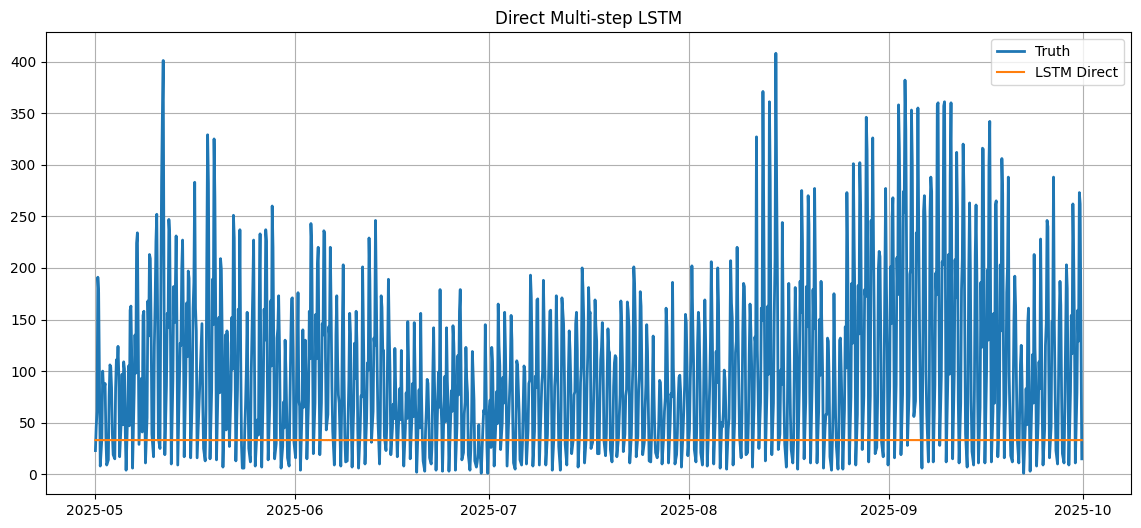

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test_truth["ds"], test_truth["y"], label="Truth", linewidth=2)
plt.plot(test_truth["ds"], multi_pred, label="LSTM Direct")

plt.legend()
plt.grid(True)
plt.title("Direct Multi-step LSTM")
plt.show()